In [110]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
import scipy.linalg as sl

# Task 7

In [111]:
# Transitions matrix
Q = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

# Parameters
n_states = len(Q)
n_sims = 1000
states = np.arange(n_states)

# Array to store results
lifetimes = np.zeros(n_sims)
reappears = 0

# Random number generator
rng = np.random.default_rng(30)

for i in range(n_sims):
    # Inital parameters
    curr_state = 0
    reappeared = 0

    t = 0

    # Transition to states until death
    while True:
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        t += rng.exponential(-1/Q[curr_state,curr_state])

        new_state = rng.choice(a=possible_states, p=-1*(Q[curr_state,possible_states])/(Q[curr_state,curr_state]))

        if (new_state == 2 and t > 30.5):
            reappeared = 1
        
        # If state is the last state (death) then stop
        if (new_state == 4):
            lifetimes[i] = t
            reappears += reappeared
            break
        
        # Update current state
        curr_state = new_state

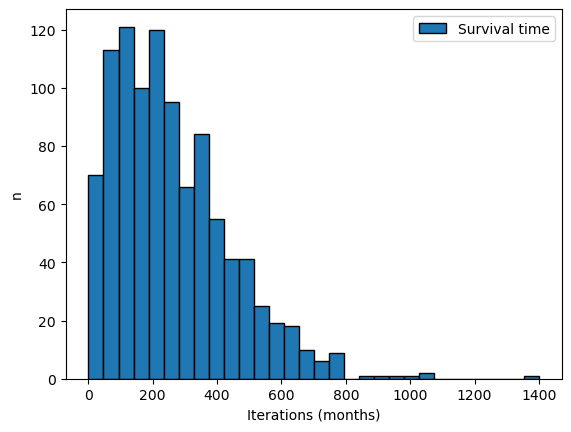

In [112]:
plt.hist(lifetimes,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

In [113]:
np.mean(lifetimes), np.std(lifetimes, ddof=1)

(260.6557758370406, 182.5444358603559)

In [114]:
reappears/n_sims

0.43

# Task 8

In [115]:
# Transitions matrix
Q = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

p0 = np.array([1,0,0,0])
Qs = Q[:-1,:-1]

FT = lambda t: 1 - p0 @ sl.expm(Qs*t) @ np.ones(4)

ts = np.arange(0,1500,1)

FT_arr = np.zeros(len(ts))
for i in range(len(ts)):
    FT_arr[i] = FT(ts[i])

ecdf_no_treatment = ss.ecdf(lifetimes)

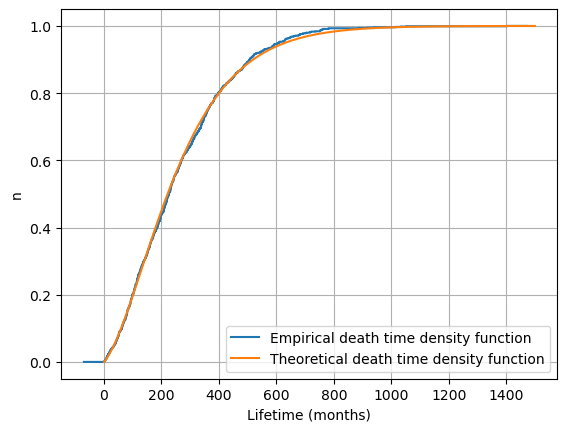

In [116]:
#plt.hist(lifetimes,bins=30, density=True, edgecolor="black", label="Survival time")
ecdf_no_treatment.cdf.plot(label='Empirical death time density function')
plt.plot(ts, FT_arr, label='Theoretical death time density function')
plt.ylabel("n")
plt.xlabel("Lifetime (months)")
plt.legend()
plt.grid()
plt.show()

# Task 9

In [117]:
# Transitions matrix
Q1 = np.array([
    [0, 0.0025, 0.00125, 0, 0.001],
    [0, 0, 0, 0.002, 0.005],
    [0, 0, 0, 0.003, 0.005],
    [0, 0, 0, 0, 0.009],
    [0, 0, 0, 0, 0]
])

for i in range(4):
    Q1[i,i] = -np.sum(Q1[i])

# Parameters
n_states = len(Q1)
n_sims = 1000
states = np.arange(n_states)

# Array to store results
lifetimes_treatment = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)

for i in range(n_sims):
    # Inital parameters
    curr_state = 0

    t = 0

    # Transition to states until death
    while True:
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        t += rng.exponential(-1/Q1[curr_state,curr_state])

        new_state = rng.choice(a=possible_states, p=-1*(Q1[curr_state,possible_states])/(Q1[curr_state,curr_state]))
        
        # If state is the last state (death) then stop
        if (new_state == 4):
            lifetimes_treatment[i] = t
            break
        
        # Update current state
        curr_state = new_state

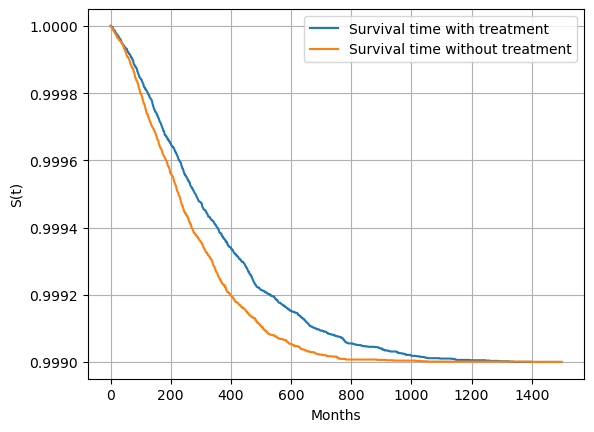

In [118]:
ecdf_treatment = ss.ecdf(lifetimes_treatment)

S_treatment = lambda t: (n_sims - ecdf_treatment.cdf.evaluate(t))/n_sims
S_no_treatment = lambda t: (n_sims - ecdf_no_treatment.cdf.evaluate(t))/n_sims

ts = np.arange(0,1500,1)

plt.plot(ts, S_treatment(ts), label='Survival time with treatment')
plt.plot(ts, S_no_treatment(ts), label='Survival time without treatment')
plt.ylabel("S(t)")
plt.xlabel("Months")
plt.legend()
plt.grid()
plt.show()

# Task 10

In [119]:
ss.logrank(lifetimes, lifetimes_treatment).pvalue

2.522823136798342e-17